# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Physical Features Attention Experiment — Full Kaggle Notebook             ║
# ║  Compares 4 models: Normal | Cost-Sensitive | QAM-Shifted | Phys-Features  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


In [1]:
# ── CELL 1: Setup ──────────────────────────────────────────────────────────────
import os, sys, subprocess

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = '/kaggle/working/amr-5-class'
DATASET  = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

if os.path.exists(WORK_DIR):
    print("Pulling latest ...")
    subprocess.run(['git', '-C', WORK_DIR, 'pull'], check=True)
else:
    subprocess.run(['git', 'clone', REPO_URL, WORK_DIR], check=True)

os.chdir(WORK_DIR)
sys.path.insert(0, WORK_DIR)

required = [
    'src/dataset.py',
    'src/train.py',
    'src/models/mcldnn_attention.py',
    'src/models/mcldnn_attention_phys.py',
    'src/features/signal_features.py',
    'src/losses/cost_sensitive.py',
    'configs/exp_5class_attention.yaml',
    'configs/exp_5class_attention_phys.yaml',
    'configs/exp_5class_attention_qam_shifted_cost.yaml',
    # Pre-trained weights from previous experiments
    'experiments/5class_attention/checkpoints/best_model.weights.h5',
    'experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5',
    'experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5',
]

all_ok = True
for p in required:
    ok = os.path.exists(p)
    if not ok: all_ok = False
    print(f"  {'✓' if ok else '✗ MISSING'}  {p}")

if not all_ok:
    raise RuntimeError("Missing files — push them to GitHub first.")
print("\nAll files present ✓")


Cloning into '/kaggle/working/amr-5-class'...


  ✓  src/dataset.py
  ✓  src/train.py
  ✓  src/models/mcldnn_attention.py
  ✓  src/models/mcldnn_attention_phys.py
  ✓  src/features/signal_features.py
  ✓  src/losses/cost_sensitive.py
  ✓  configs/exp_5class_attention.yaml
  ✓  configs/exp_5class_attention_phys.yaml
  ✓  configs/exp_5class_attention_qam_shifted_cost.yaml
  ✓  experiments/5class_attention/checkpoints/best_model.weights.h5
  ✓  experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5
  ✓  experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5

All files present ✓


In [2]:
# ── CELL 2: Verify physical features and model shape ──────────────────────────
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
keras.mixed_precision.set_global_policy('float32')
print(f"Keras policy: {keras.mixed_precision.global_policy()}")

import numpy as np
from src.features.signal_features import (
    extract_amplitude, extract_phase_sincos, prepare_physical_features
)
from src.models.mcldnn_attention_phys import (
    build_mcldnn_attention_phys, build_mcldnn_attention_phys_extractor
)

# Quick feature check on synthetic IQ
np.random.seed(42)
X_fake = np.random.randn(10, 2, 128).astype('float32')
amp, phase = prepare_physical_features(X_fake)
print(f"Amplitude shape   : {amp.shape}    (expect (10, 128, 1))")
print(f"Phase shape       : {phase.shape}  (expect (10, 128, 2))")
print(f"Amplitude range   : [{amp.min():.3f}, {amp.max():.3f}]  (expect ≥ 0)")
print(f"Phase cos range   : [{phase[:,:,0].min():.3f}, {phase[:,:,0].max():.3f}]  (expect [-1, 1])")
print(f"Phase sin range   : [{phase[:,:,1].min():.3f}, {phase[:,:,1].max():.3f}]  (expect [-1, 1])")
assert amp.min() >= 0, "Amplitude must be non-negative"
assert phase[:,:,0].min() >= -1 and phase[:,:,0].max() <= 1

# Physical phase norm check: cos²+sin² = 1
norm = (phase[:,:,0]**2 + phase[:,:,1]**2)
print(f"cos²+sin² range   : [{norm.min():.3f}, {norm.max():.3f}]  (expect ≈ 1.0)")
assert np.allclose(norm, 1.0, atol=1e-4), "Phase unit vector norm failed"
print("\nFeature checks PASSED ✓")

# Model check
model_phys = build_mcldnn_attention_phys(classes=5)
print(f"\nModel params: {model_phys.count_params():,}")
print(f"Under 300k: {'✓' if model_phys.count_params() < 300_000 else '✗ FAIL'}")

d1 = np.zeros((4,2,128,1),'float32')
d2 = np.zeros((4,128,1),'float32')
d3 = np.zeros((4,128,1),'float32')
d4 = np.zeros((4,128,1),'float32')
d5 = np.zeros((4,128,2),'float32')
out = model_phys.predict([d1,d2,d3,d4,d5], verbose=0)
assert out.shape == (4,5), f"Wrong output shape: {out.shape}"
print(f"Output shape: {out.shape} ✓")
del model_phys


2026-06-26 19:30:56.117761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782502256.303679      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782502256.361424      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782502256.801156      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782502256.801209      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782502256.801212      58 computation_placer.cc:177] computation placer alr

Keras policy: <DTypePolicy "float32">
Amplitude shape   : (10, 128, 1)    (expect (10, 128, 1))
Phase shape       : (10, 128, 2)  (expect (10, 128, 2))
Amplitude range   : [0.053, 3.208]  (expect ≥ 0)
Phase cos range   : [-1.000, 1.000]  (expect [-1, 1])
Phase sin range   : [-1.000, 1.000]  (expect [-1, 1])
cos²+sin² range   : [1.000, 1.000]  (expect ≈ 1.0)

Feature checks PASSED ✓


I0000 00:00:1782502273.091168      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Model params: 257,913
Under 300k: ✓


I0000 00:00:1782502275.208766     134 service.cc:152] XLA service 0x78d5d0004360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782502275.208814     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782502275.453836     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


Output shape: (4, 5) ✓


I0000 00:00:1782502277.388541     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [3]:
# ── CELL 3: Train physical features model ─────────────────────────────────────
print("=" * 65)
print("  Training: MCLDNN-Attention + Amplitude & Phase Features")
print("  Config  : configs/exp_5class_attention_phys.yaml")
print("=" * 65)

!python src/train.py \
    --config configs/exp_5class_attention_phys.yaml \
    --datasetpath {DATASET}

ckpt_phys = 'experiments/5class_attention_phys/checkpoints/best_model.weights.h5'
if os.path.exists(ckpt_phys):
    print(f"\n✓ Checkpoint saved: {ckpt_phys}  "
          f"({os.path.getsize(ckpt_phys)/1e6:.1f} MB)")
else:
    raise RuntimeError(f"Checkpoint not found: {ckpt_phys}")


  Training: MCLDNN-Attention + Amplitude & Phase Features
  Config  : configs/exp_5class_attention_phys.yaml
2026-06-26 19:31:18.153471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782502278.180257     189 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782502278.189086     189 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782502278.210923     189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782502278.210972     189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same t

In [4]:
# ── CELL 4: Load all 4 models + dataset ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.dataset import load_data, FIVE_CLASS
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn_attention_phys import build_mcldnn_attention_phys
from src.losses.cost_sensitive import (
    build_cost_matrix, CostSensitiveCrossEntropy
)
from src.features.signal_features import prepare_physical_features

os.makedirs('experiments/comparison_all4/figures', exist_ok=True)
os.makedirs('experiments/comparison_all4/results',  exist_ok=True)

CLASSES = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

# ── Load dataset ──────────────────────────────────────────────────────────────
print("Loading full dataset (all 20 SNRs) ...")
(mods, snrs, lbl), \
(X_train, Y_train), (X_val, Y_val), (X_test, Y_test), \
(train_idx, val_idx, test_idx) = load_data(DATASET, FIVE_CLASS, seed=2016)

test_SNRs = np.array([lbl[test_idx[j]][1] for j in range(len(test_idx))])
ALL_SNRS  = sorted(set(test_SNRs))
print(f"Test samples: {len(Y_test)}  |  SNRs: {ALL_SNRS}")

# ── Prepare inputs ─────────────────────────────────────────────────────────────
def make_base_inputs(X):
    return [
        np.expand_dims(X, 3).astype('float32'),
        np.expand_dims(X[:,0,:], 2).astype('float32'),
        np.expand_dims(X[:,1,:], 2).astype('float32'),
    ]

def make_phys_inputs(X):
    base = make_base_inputs(X)
    amp, phase = prepare_physical_features(X)
    return base + [amp, phase]

inp_test      = make_base_inputs(X_test)
inp_test_phys = make_phys_inputs(X_test)

print("Inputs prepared ✓")

# ── Load model 1: Normal Attention ────────────────────────────────────────────
print("\nLoading models ...")
m1 = build_mcldnn_attention(classes=5)
m1.load_weights('experiments/5class_attention/checkpoints/best_model.weights.h5')
print(f"  [1] Normal Attention        params={m1.count_params():,}")

# ── Load model 2: Cost-Sensitive Attention ────────────────────────────────────
C = build_cost_matrix(
    classes=CLASSES,
    high_cost_pairs=[('QAM16','QAM64'),('QAM64','QAM16')],
    alpha=1.5,
    correct_class_costs={'QAM16':-1.0,'QAM64':-1.0},
)
loss_cs = CostSensitiveCrossEntropy(C, label_smoothing=0.1)
m2 = build_mcldnn_attention(classes=5)
m2.compile(loss=loss_cs, optimizer='adam', metrics=['accuracy'])
m2.load_weights('experiments/5class_attention_costsensitive/checkpoints/best_model.weights.h5')
print(f"  [2] Cost-Sensitive Attn     params={m2.count_params():,}")

# ── Load model 3: QAM-Shifted Cost ────────────────────────────────────────────
m3 = build_mcldnn_attention(classes=5)
m3.compile(loss=loss_cs, optimizer='adam', metrics=['accuracy'])
m3.load_weights('experiments/5class_attention_qam_shifted_cost/checkpoints/best_model.weights.h5')
print(f"  [3] QAM-Shifted Cost Attn   params={m3.count_params():,}")

# ── Load model 4: Physical Features Attention ─────────────────────────────────
m4 = build_mcldnn_attention_phys(classes=5)
m4.load_weights('experiments/5class_attention_phys/checkpoints/best_model.weights.h5')
print(f"  [4] Phys-Features Attn      params={m4.count_params():,}")

MODELS = [
    ('Normal Attn',        m1, inp_test,      '#1f77b4'),
    ('Cost-Sensitive',     m2, inp_test,      '#ff7f0e'),
    ('QAM-Shifted Cost',   m3, inp_test,      '#2ca02c'),
    ('Phys Features Attn', m4, inp_test_phys, '#d62728'),
]


Loading full dataset (all 20 SNRs) ...
[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Test samples: 20000  |  SNRs: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
Inputs prepared ✓

Loading models ...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  [1] Normal Attention        params=244,341
  [2] Cost-Sensitive Attn     params=244,341
  [3] QAM-Shifted Cost Attn   params=244,341
  [4] Phys-Features Attn      params=257,913


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
# ── CELL 5: Per-SNR accuracy for all 4 models ─────────────────────────────────
print(f"\n{'='*80}")
print(f"  {'SNR':>5}  {'Normal':>10}  {'Cost-Sens':>11}  "
      f"{'QAM-Shift':>11}  {'Phys-Feat':>11}")
print(f"  {'─'*70}")

rows = []
for snr in ALL_SNRS:
    mask = test_SNRs == snr
    row  = {'snr': snr}
    accs = []
    for name, model, inp, _ in MODELS:
        inp_s = [x[mask] for x in inp]
        acc   = model.evaluate(inp_s, Y_test[mask],
                               verbose=0, batch_size=400)[1]
        key   = name.lower().replace(' ','_').replace('-','_')
        row[key] = acc
        accs.append(acc)
    rows.append(row)
    print(f"  {snr:>5} dB  "
          f"{accs[0]*100:>9.2f}%  {accs[1]*100:>10.2f}%  "
          f"{accs[2]*100:>10.2f}%  {accs[3]*100:>10.2f}%")

print(f"  {'─'*70}")
df = pd.DataFrame(rows)

# Column name mapping (safe keys)
col_map = {
    'Normal Attn':        'normal_attn',
    'Cost-Sensitive':     'cost_sensitive',
    'QAM-Shifted Cost':   'qam_shifted_cost',
    'Phys Features Attn': 'phys_features_attn',
}
means = {n: df[col_map[n]].mean() for n,_,_,_ in MODELS}
print(f"  {'Mean':>5}   ", end='')
for name, _, _, _ in MODELS:
    print(f"{means[name]*100:>10.2f}%  ", end='')
print()
print(f"{'='*80}")

df.to_csv('experiments/comparison_all4/results/all4_per_snr.csv', index=False)
print("\n[SAVED] experiments/comparison_all4/results/all4_per_snr.csv")



    SNR      Normal    Cost-Sens    QAM-Shift    Phys-Feat
  ──────────────────────────────────────────────────────────────────────
    -20 dB      32.90%       34.40%       33.00%       33.30%
    -18 dB      30.90%       33.20%       32.10%       31.30%
    -16 dB      32.00%       33.40%       33.30%       32.80%
    -14 dB      31.70%       32.30%       33.70%       31.90%
    -12 dB      30.30%       32.60%       31.50%       31.50%
    -10 dB      27.60%       33.10%       29.40%       29.60%
     -8 dB      28.30%       31.00%       29.10%       27.70%
     -6 dB      32.40%       33.90%       33.70%       29.00%
     -4 dB      40.00%       43.60%       45.00%       40.40%
     -2 dB      57.20%       59.00%       59.10%       56.90%
      0 dB      76.00%       73.20%       72.60%       74.30%
      2 dB      83.40%       80.90%       78.10%       81.00%
      4 dB      88.10%       84.30%       79.80%       88.00%
      6 dB      88.80%       86.30%       78.70%       85.60%

In [6]:
# ── CELL 6: QAM & PSK confusion rates for all 4 models ───────────────────────
from sklearn.metrics import confusion_matrix

qam16_idx = CLASSES.index('QAM16')
qam64_idx = CLASSES.index('QAM64')
qpsk_idx  = CLASSES.index('QPSK')
psk8_idx  = CLASSES.index('8PSK')

def confusion_pair(pred, true, a, b):
    mask_a = true == a
    mask_b = true == b
    r_a2b  = (pred[mask_a] == b).mean() if mask_a.sum() > 0 else 0.0
    r_b2a  = (pred[mask_b] == a).mean() if mask_b.sum() > 0 else 0.0
    return r_a2b, r_b2a

true_labels = np.argmax(Y_test, axis=1)
conf_rows   = []

print(f"\n{'Model':<22}  {'QAM16→64':>10}  {'QAM64→16':>10}  "
      f"{'QPSK→8PSK':>11}  {'8PSK→QPSK':>11}")
print("-" * 70)

for name, model, inp, color in MODELS:
    preds = np.argmax(model.predict(inp, verbose=0, batch_size=400), axis=1)
    r16_64, r64_16 = confusion_pair(preds, true_labels, qam16_idx, qam64_idx)
    rQP_8,  r8_QP  = confusion_pair(preds, true_labels, qpsk_idx,  psk8_idx)
    conf_rows.append({
        'model': name,
        'qam16_to_qam64': r16_64, 'qam64_to_qam16': r64_16,
        'qpsk_to_8psk':   rQP_8,  '8psk_to_qpsk':   r8_QP,
    })
    print(f"  {name:<20}  {r16_64*100:>9.2f}%  {r64_16*100:>9.2f}%  "
          f"{rQP_8*100:>10.2f}%  {r8_QP*100:>10.2f}%")

df_conf = pd.DataFrame(conf_rows)
df_conf.to_csv('experiments/comparison_all4/results/confusion_pairs.csv',
               index=False)
print("\n[SAVED] experiments/comparison_all4/results/confusion_pairs.csv")



Model                     QAM16→64    QAM64→16    QPSK→8PSK    8PSK→QPSK
----------------------------------------------------------------------
  Normal Attn               22.55%      36.80%        8.22%        5.58%
  Cost-Sensitive            16.48%      26.67%       23.80%        8.43%
  QAM-Shifted Cost          17.38%      48.98%       16.68%       10.45%
  Phys Features Attn        11.70%      42.20%       14.60%        9.65%

[SAVED] experiments/comparison_all4/results/confusion_pairs.csv


[SAVED] experiments/comparison_all4/figures/main_4model_comparison.png


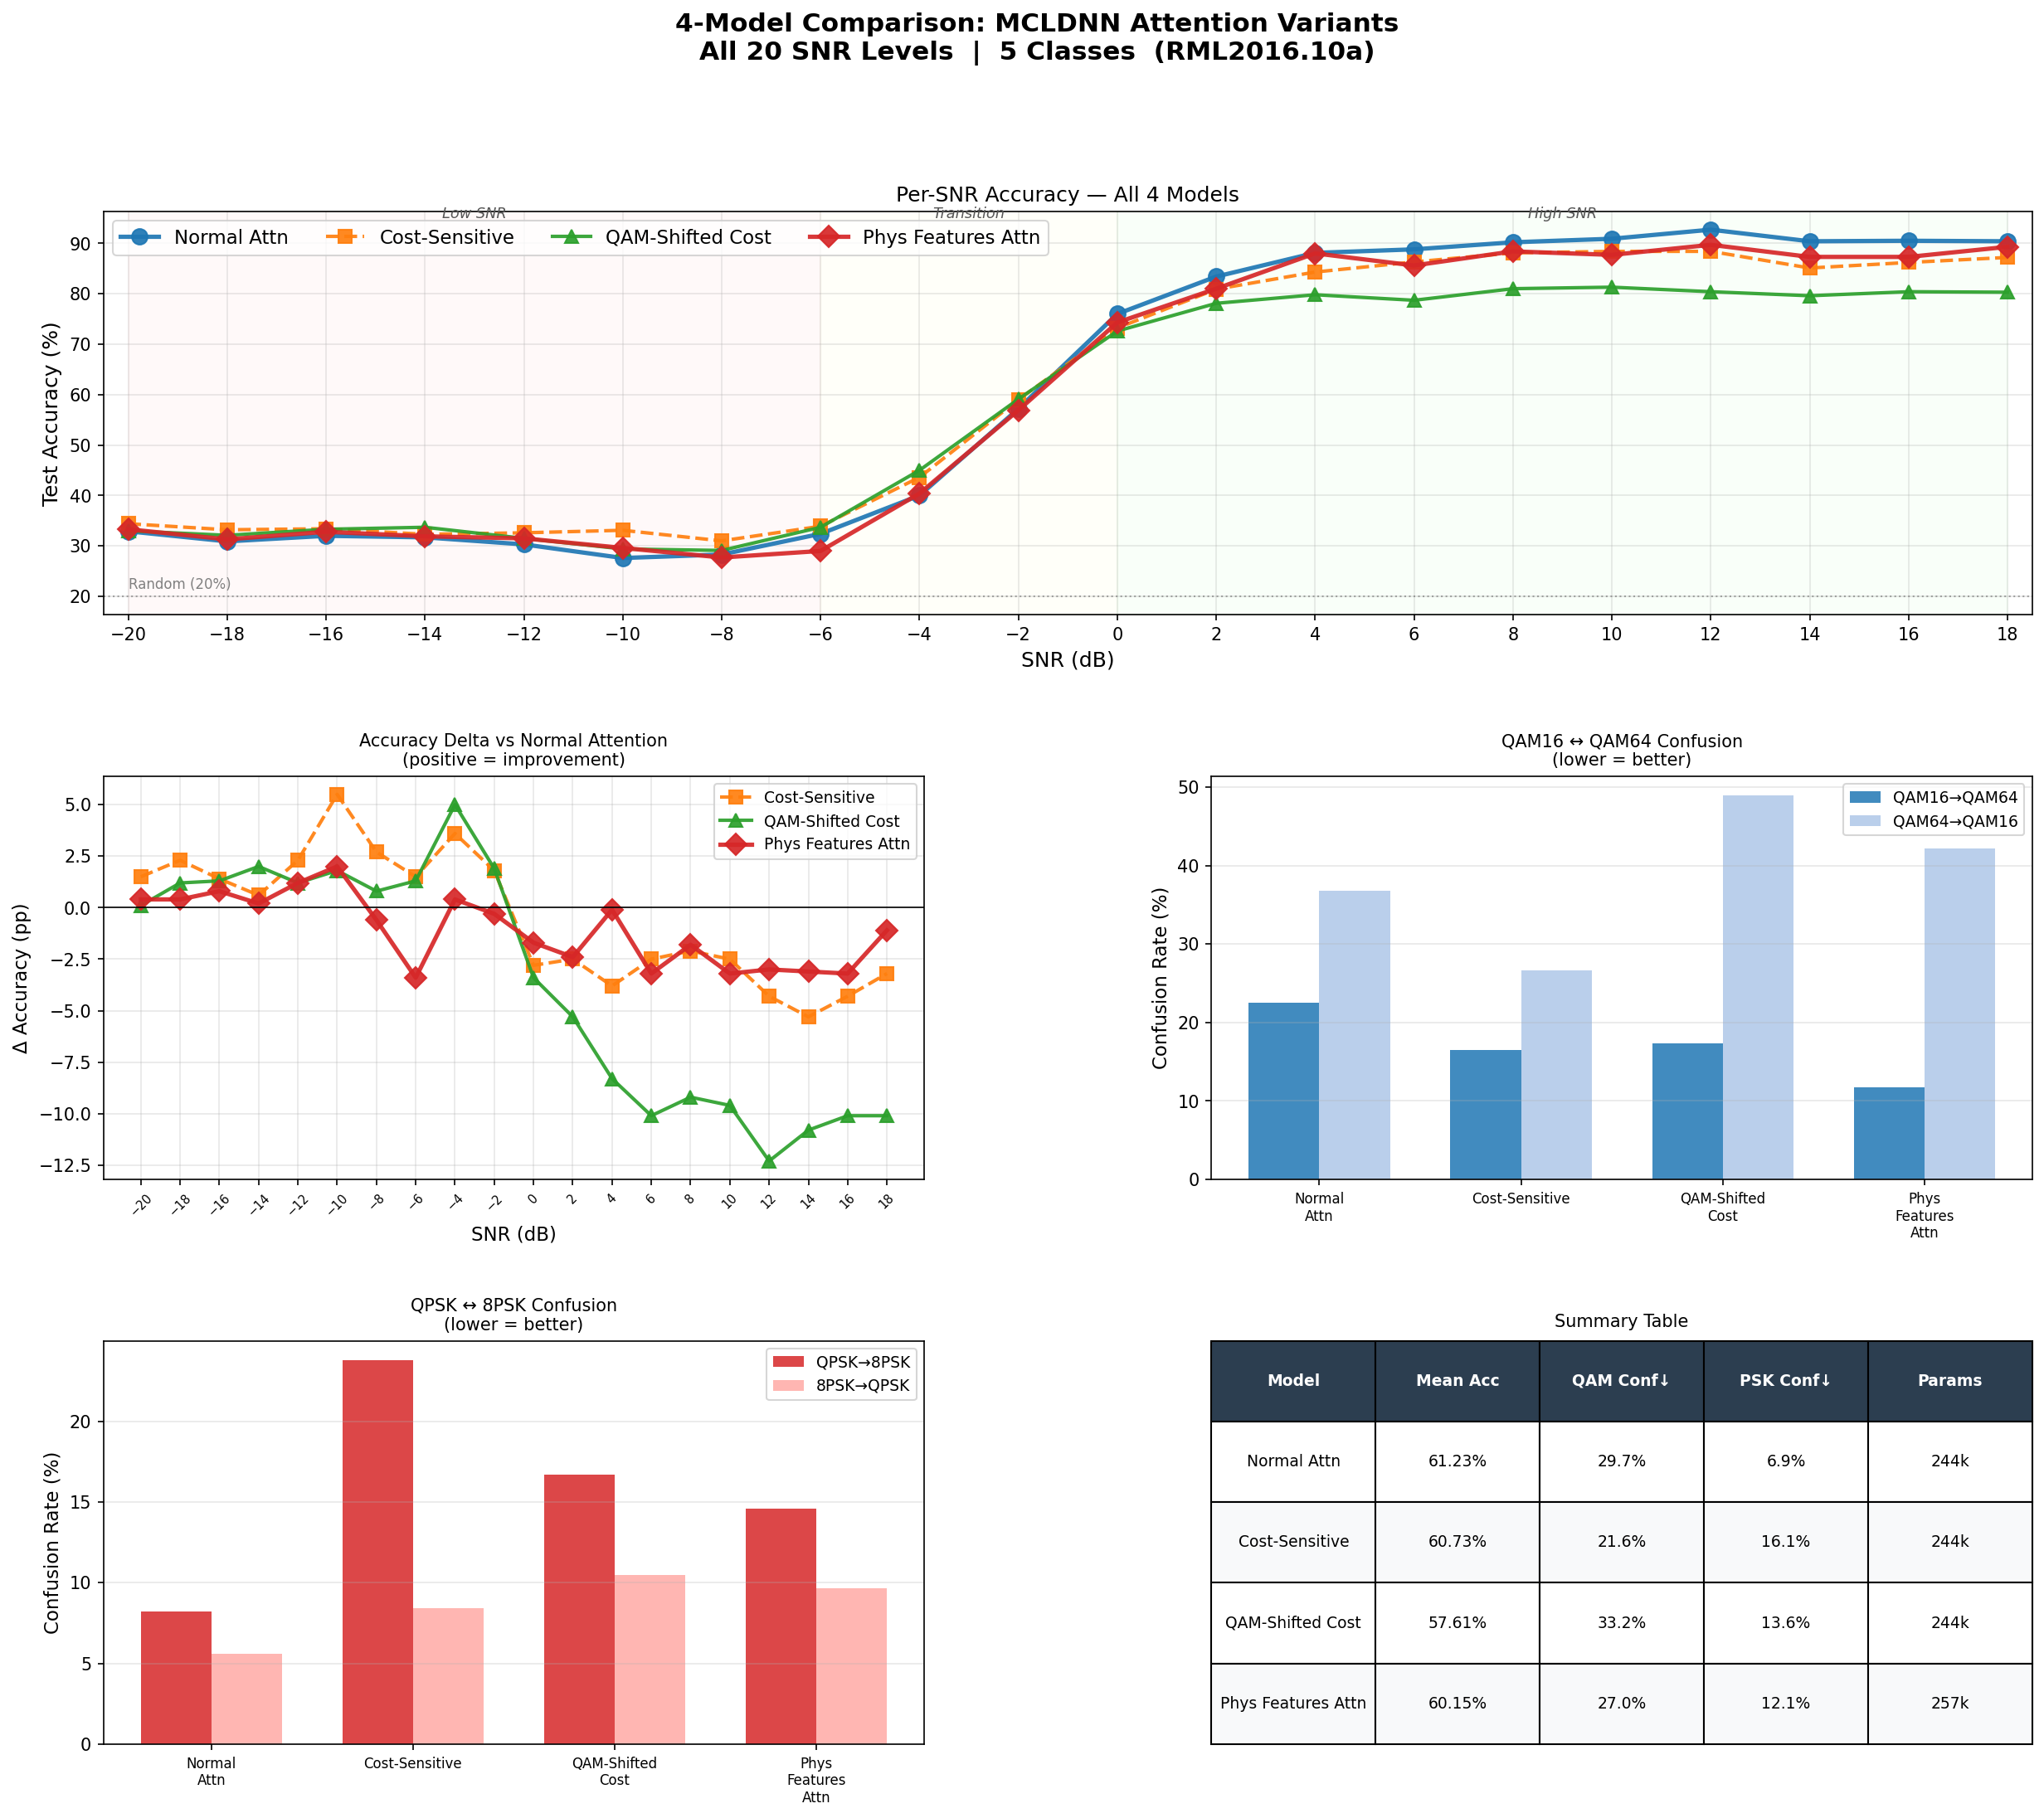

In [7]:
# ── CELL 7: MAIN 4-model comparison plot ──────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('4-Model Comparison: MCLDNN Attention Variants\n'
             'All 20 SNR Levels  |  5 Classes  (RML2016.10a)',
             fontsize=15, fontweight='bold')

gs  = fig.add_gridspec(3, 2, hspace=0.40, wspace=0.35)
snr_arr = df['snr'].values

style = {
    'Normal Attn':        ('o-', 2.5, 9, '#1f77b4'),
    'Cost-Sensitive':     ('s--',2.0, 8, '#ff7f0e'),
    'QAM-Shifted Cost':   ('^-', 2.0, 8, '#2ca02c'),
    'Phys Features Attn': ('D-', 2.5, 9, '#d62728'),
}

# ── Panel 1: Full accuracy curve ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for name, _, _, _ in MODELS:
    mk, lw, ms, col = style[name]
    key = col_map[name]
    ax1.plot(snr_arr, df[key]*100, mk, color=col,
             linewidth=lw, markersize=ms, label=name, alpha=0.92)
ax1.axhline(20, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax1.text(snr_arr[0], 21.5, 'Random (20%)', fontsize=8, color='gray')
# Shade regimes
ax1.axvspan(-20, -6, color='#fee', alpha=0.35, zorder=0)
ax1.axvspan(-6,   0, color='#ffe', alpha=0.35, zorder=0)
ax1.axvspan(0,   18, color='#efe', alpha=0.35, zorder=0)
for x, lbl_t in [(-13,'Low SNR'), (-3,'Transition'), (9,'High SNR')]:
    ax1.text(x, 95, lbl_t, ha='center', fontsize=8.5,
             color='#555', style='italic')
ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Per-SNR Accuracy — All 4 Models', fontsize=12)
ax1.legend(fontsize=11, ncol=4, loc='upper left')
ax1.grid(True, alpha=0.3); ax1.set_xticks(snr_arr)
ax1.set_xlim(snr_arr[0]-0.5, snr_arr[-1]+0.5)

# ── Panel 2: Delta vs Normal Attention ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
base_key = col_map['Normal Attn']
for name, _, _, _ in MODELS[1:]:    # skip Normal (delta = 0)
    mk, lw, ms, col = style[name]
    key = col_map[name]
    delta = (df[key] - df[base_key]) * 100
    ax2.plot(snr_arr, delta, mk, color=col,
             linewidth=lw, markersize=ms, label=name, alpha=0.92)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.fill_between(snr_arr, 0, 0, alpha=0)   # placeholder
ax2.set_xlabel('SNR (dB)', fontsize=11)
ax2.set_ylabel('Δ Accuracy (pp)', fontsize=11)
ax2.set_title('Accuracy Delta vs Normal Attention\n(positive = improvement)',
              fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_xticks(snr_arr)
plt.setp(ax2.get_xticklabels(), rotation=45, fontsize=7)

# ── Panel 3: QAM16↔QAM64 confusion reduction ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
names_bar = [r['model'] for r in conf_rows]
x = np.arange(len(names_bar))
w = 0.35
ax3.bar(x - w/2, [r['qam16_to_qam64']*100 for r in conf_rows],
        w, label='QAM16→QAM64', color='#1f77b4', alpha=0.85)
ax3.bar(x + w/2, [r['qam64_to_qam16']*100 for r in conf_rows],
        w, label='QAM64→QAM16', color='#aec7e8', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels([n.replace(' ','\n') for n in names_bar], fontsize=8)
ax3.set_ylabel('Confusion Rate (%)', fontsize=11)
ax3.set_title('QAM16 ↔ QAM64 Confusion\n(lower = better)', fontsize=10)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: QPSK↔8PSK confusion reduction ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(x - w/2, [r['qpsk_to_8psk']*100 for r in conf_rows],
        w, label='QPSK→8PSK', color='#d62728', alpha=0.85)
ax4.bar(x + w/2, [r['8psk_to_qpsk']*100 for r in conf_rows],
        w, label='8PSK→QPSK', color='#ffaaa5', alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels([n.replace(' ','\n') for n in names_bar], fontsize=8)
ax4.set_ylabel('Confusion Rate (%)', fontsize=11)
ax4.set_title('QPSK ↔ 8PSK Confusion\n(lower = better)', fontsize=10)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')

# ── Panel 5: Summary table ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')
table_data  = [['Model', 'Mean Acc', 'QAM Conf↓', 'PSK Conf↓', 'Params']]
for i, (name, model, _, _) in enumerate(MODELS):
    r   = conf_rows[i]
    qam = (r['qam16_to_qam64'] + r['qam64_to_qam16']) / 2 * 100
    psk = (r['qpsk_to_8psk']   + r['8psk_to_qpsk'])   / 2 * 100
    table_data.append([
        name,
        f"{means[name]*100:.2f}%",
        f"{qam:.1f}%",
        f"{psk:.1f}%",
        f"{model.count_params()//1000}k",
    ])
tbl = ax5.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f8f9fa')
ax5.set_title('Summary Table', fontsize=10, pad=8)

p1 = 'experiments/comparison_all4/figures/main_4model_comparison.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p1}")
display(Image(p1))


[SAVED] experiments/comparison_all4/figures/confusion_4models.png


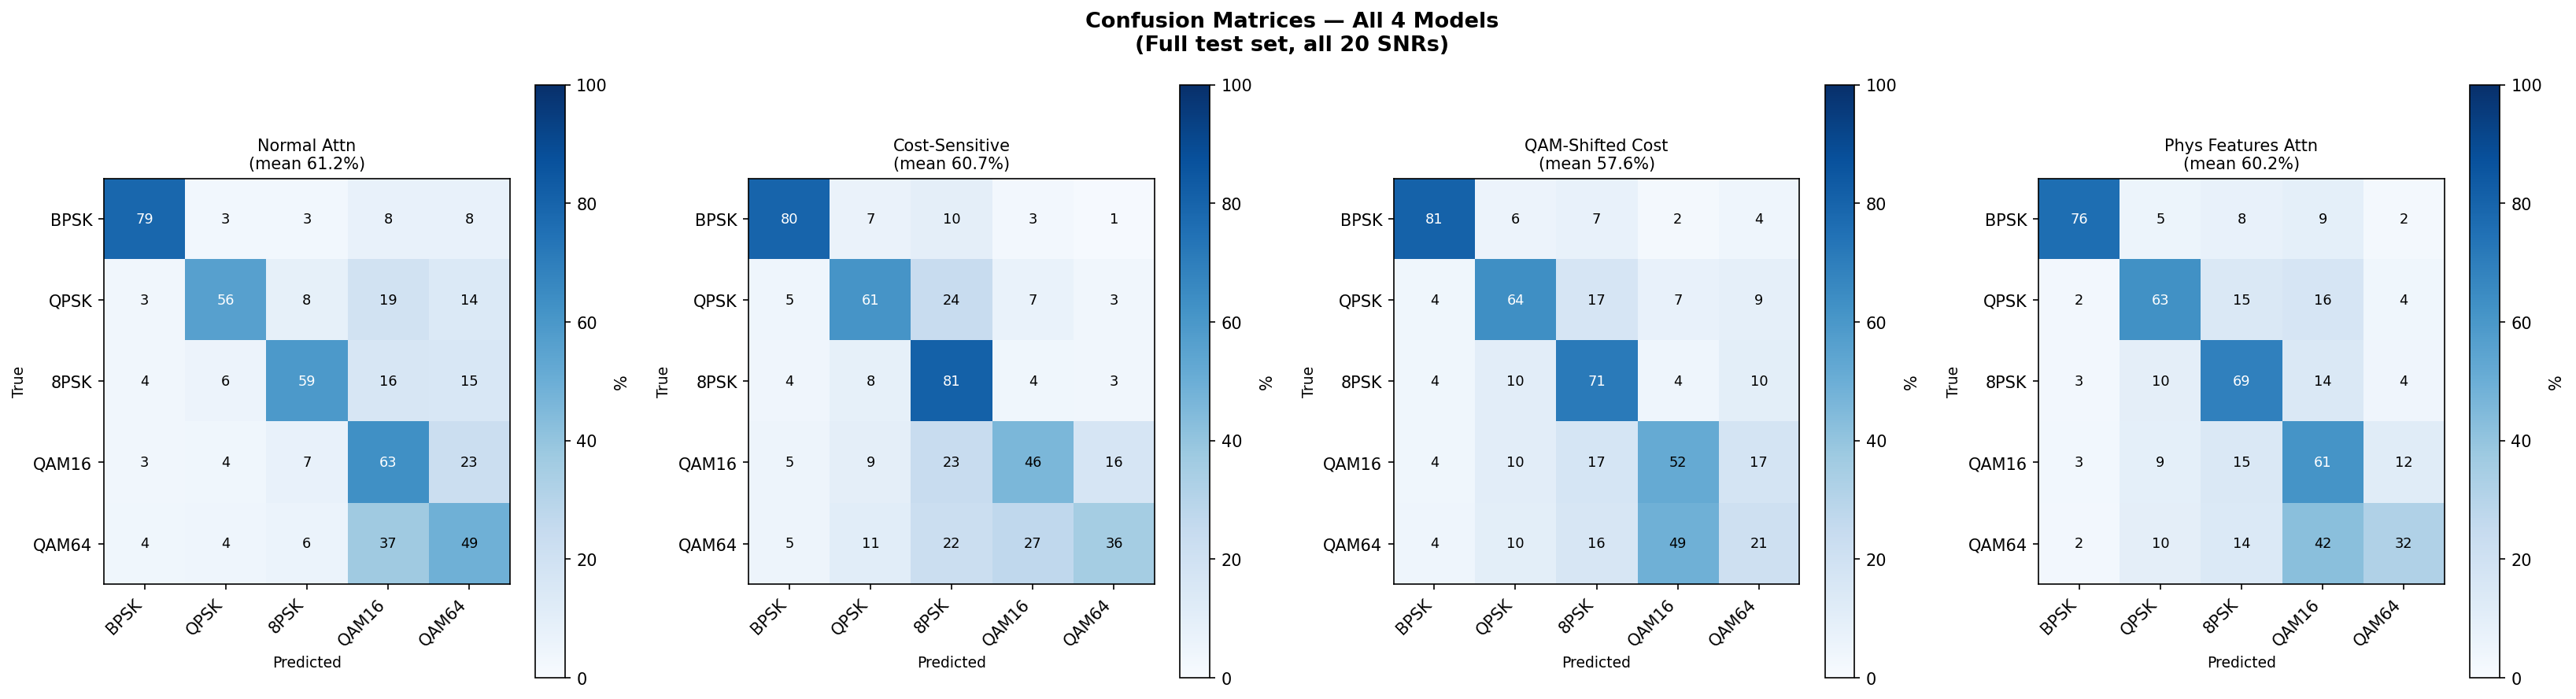

In [8]:
# ── CELL 8: Per-class accuracy heatmaps (all 4 models) ────────────────────────
from sklearn.metrics import confusion_matrix as sk_cm

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Confusion Matrices — All 4 Models\n(Full test set, all 20 SNRs)',
             fontsize=13, fontweight='bold')

true_labels = np.argmax(Y_test, axis=1)
for ax, (name, model, inp, color) in zip(axes, MODELS):
    pred = np.argmax(model.predict(inp, verbose=0, batch_size=400), axis=1)
    cm   = sk_cm(true_labels, pred, normalize='true') * 100
    im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label='%')
    ax.set_xticks(range(5)); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(5)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True',      fontsize=9)
    ax.set_title(f'{name}\n(mean {means[name]*100:.1f}%)', fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm[i,j]:.0f}',
                    ha='center', va='center', fontsize=8.5,
                    color='white' if cm[i,j] > 55 else 'black')

plt.tight_layout()
p2 = 'experiments/comparison_all4/figures/confusion_4models.png'
fig.savefig(p2, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p2}")
display(Image(p2))


[SAVED] experiments/comparison_all4/figures/regime_breakdown.png


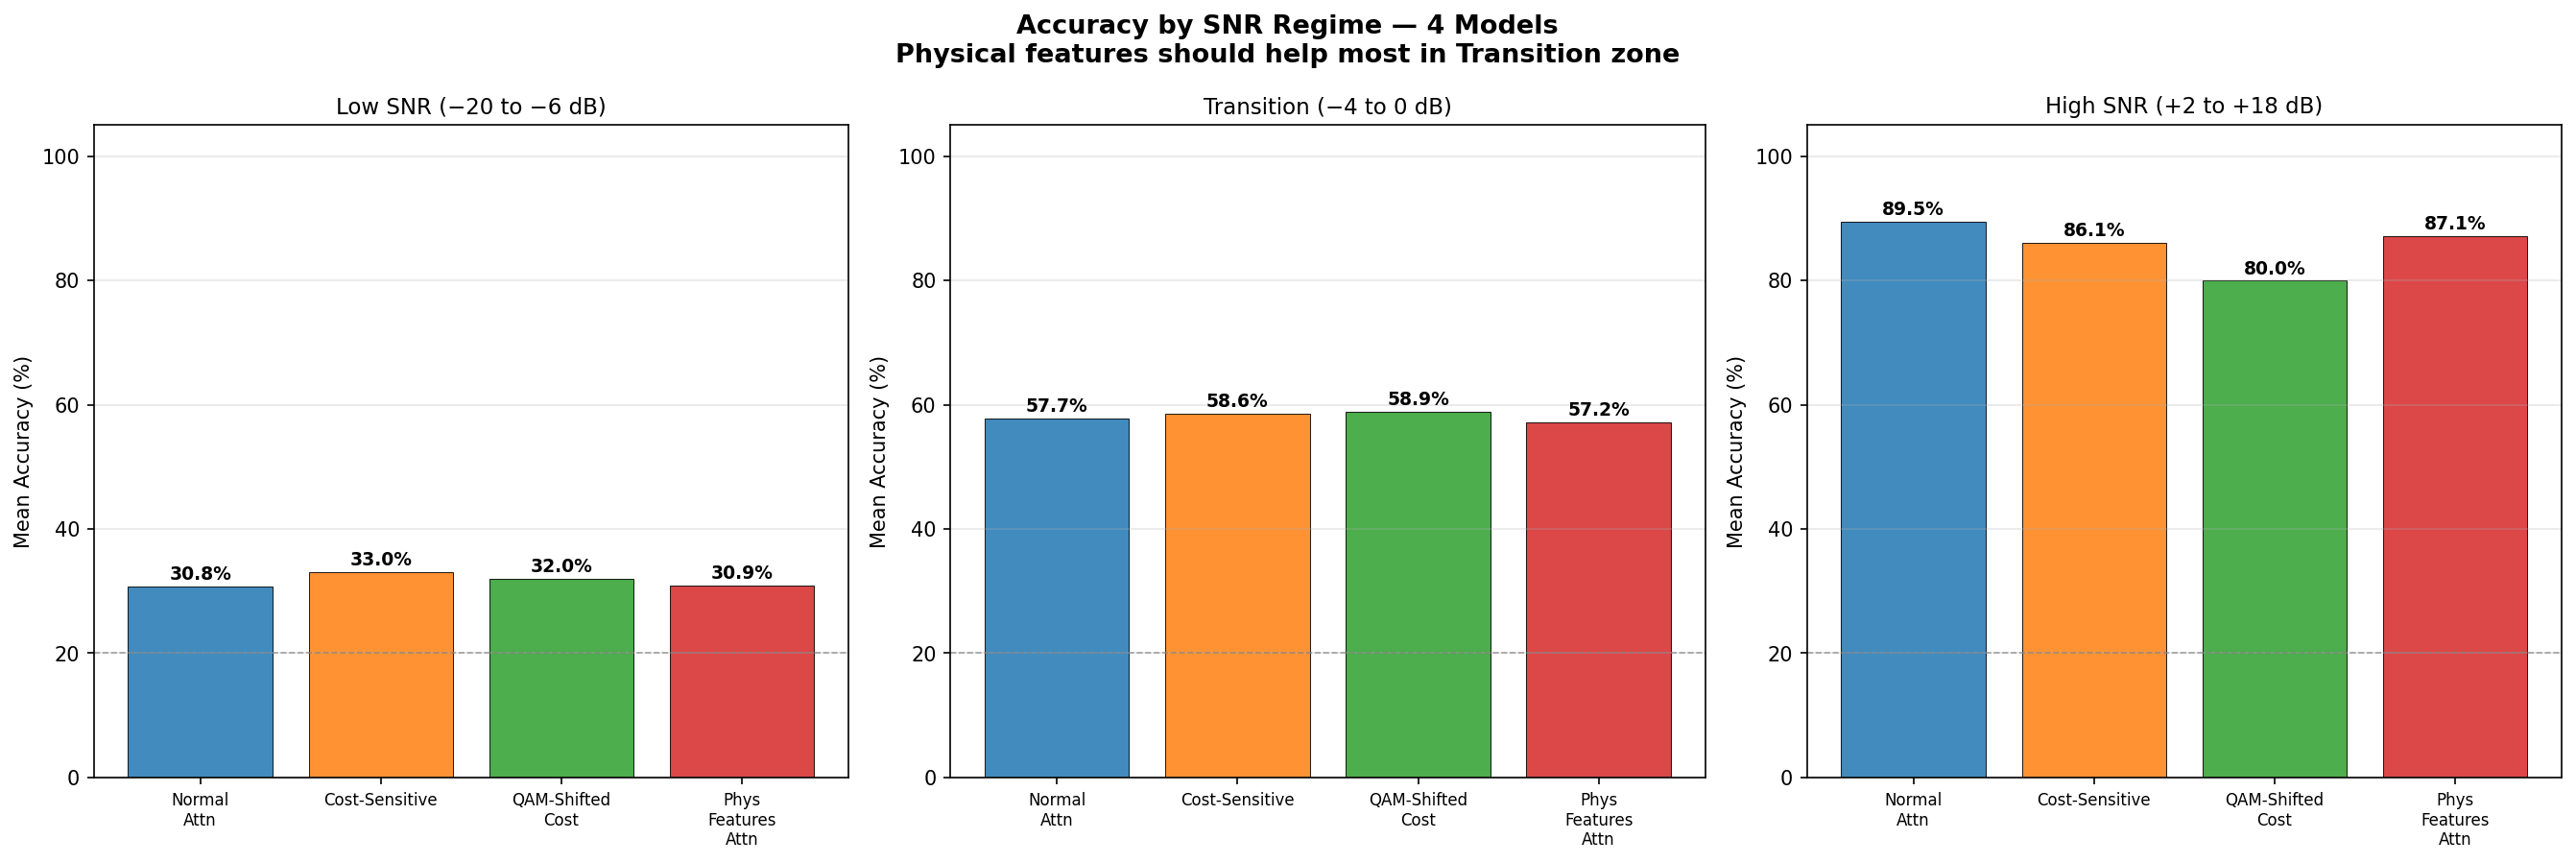

In [9]:
# ── CELL 9: Low / mid / high SNR regime breakdown ─────────────────────────────
regimes = {
    'Low SNR (−20 to −6 dB)':   [s for s in ALL_SNRS if s <= -6],
    'Transition (−4 to 0 dB)':  [s for s in ALL_SNRS if -4 <= s <= 0],
    'High SNR (+2 to +18 dB)':  [s for s in ALL_SNRS if s >= 2],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Accuracy by SNR Regime — 4 Models\n'
             'Physical features should help most in Transition zone',
             fontsize=13, fontweight='bold')

for ax, (regime_name, regime_snrs) in zip(axes, regimes.items()):
    regime_accs = {}
    for name, model, inp, color in MODELS:
        key = col_map[name]
        mask = df['snr'].isin(regime_snrs)
        regime_accs[name] = df.loc[mask, key].mean() * 100

    names_r = list(regime_accs.keys())
    vals_r  = list(regime_accs.values())
    colors_r = [style[n][3] for n in names_r]

    bars = ax.bar(range(len(names_r)), vals_r,
                  color=colors_r, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals_r):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names_r)))
    ax.set_xticklabels([n.replace(' ','\n') for n in names_r], fontsize=8)
    ax.set_ylabel('Mean Accuracy (%)', fontsize=10)
    ax.set_title(regime_name, fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(20, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
p3 = 'experiments/comparison_all4/figures/regime_breakdown.png'
fig.savefig(p3, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f"[SAVED] {p3}")
display(Image(p3))


In [10]:
# ── CELL 10: Training history for physical features model ─────────────────────
log_phys = 'experiments/5class_attention_phys/results/log.csv'

if os.path.exists(log_phys):
    log = pd.read_csv(log_phys)
    val_acc_col = next((c for c in log.columns if 'val' in c and 'acc' in c),
                       'val_accuracy')
    acc_col     = next((c for c in log.columns if 'acc' in c and 'val' not in c),
                       'accuracy')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Physical Features Attention — Training History',
                 fontsize=13, fontweight='bold')

    axes[0].plot(log['epoch'], log['loss'],     '#d62728', linewidth=2,
                 label='Train loss')
    axes[0].plot(log['epoch'], log['val_loss'], '#1f77b4', linewidth=2,
                 label='Val loss')
    best_e = log['val_loss'].idxmin()
    axes[0].axvline(best_e, color='gray', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss  (best epoch={best_e})', fontsize=10)
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(log['epoch'], log[acc_col]*100,     '#d62728', linewidth=2,
                 label='Train acc')
    axes[1].plot(log['epoch'], log[val_acc_col]*100, '#1f77b4', linewidth=2,
                 label='Val acc')
    axes[1].axhline(20, color='gray', linestyle=':', linewidth=0.8)
    axes[1].axvline(best_e, color='gray', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(
        f'Accuracy  (best val_acc={log.loc[best_e,val_acc_col]*100:.2f}%)',
        fontsize=10)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    p4 = 'experiments/comparison_all4/figures/phys_training_history.png'
    fig.savefig(p4, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"[SAVED] {p4}")
    display(Image(p4))
else:
    print(f"[WARN] {log_phys} not found")


[WARN] experiments/5class_attention_phys/results/log.csv not found


In [11]:
# ── CELL 11: Full numerical results ───────────────────────────────────────────
print("\n" + "=" * 85)
print("  COMPLETE PER-SNR RESULTS TABLE")
print("=" * 85)
print(f"  {'SNR':>5}  {'Normal':>10}  {'CostSens':>10}  "
      f"{'QAMShift':>10}  {'PhysFeat':>10}  {'Best':>14}")
print("  " + "─" * 75)

for _, row in df.iterrows():
    vals = {
        'Normal':   row[col_map['Normal Attn']],
        'CostSens': row[col_map['Cost-Sensitive']],
        'QAMShift': row[col_map['QAM-Shifted Cost']],
        'PhysFeat': row[col_map['Phys Features Attn']],
    }
    best_model = max(vals, key=vals.get)
    best_val   = vals[best_model]
    print(f"  {int(row['snr']):>5} dB  "
          + "  ".join(f"{v*100:>9.2f}%" for v in vals.values())
          + f"  {best_model:>10} ({best_val*100:.2f}%)")

print("  " + "─" * 75)
print(f"  {'Mean':>5}   "
      + "  ".join(f"{df[col_map[n]].mean()*100:>9.2f}%" for n,_,_,_ in MODELS))
print("=" * 85)



  COMPLETE PER-SNR RESULTS TABLE
    SNR      Normal    CostSens    QAMShift    PhysFeat            Best
  ───────────────────────────────────────────────────────────────────────────
    -20 dB      32.90%      34.40%      33.00%      33.30%    CostSens (34.40%)
    -18 dB      30.90%      33.20%      32.10%      31.30%    CostSens (33.20%)
    -16 dB      32.00%      33.40%      33.30%      32.80%    CostSens (33.40%)
    -14 dB      31.70%      32.30%      33.70%      31.90%    QAMShift (33.70%)
    -12 dB      30.30%      32.60%      31.50%      31.50%    CostSens (32.60%)
    -10 dB      27.60%      33.10%      29.40%      29.60%    CostSens (33.10%)
     -8 dB      28.30%      31.00%      29.10%      27.70%    CostSens (31.00%)
     -6 dB      32.40%      33.90%      33.70%      29.00%    CostSens (33.90%)
     -4 dB      40.00%      43.60%      45.00%      40.40%    QAMShift (45.00%)
     -2 dB      57.20%      59.00%      59.10%      56.90%    QAMShift (59.10%)
      0 dB      

In [12]:
# ── CELL 12: Zip all phys experiment outputs + comparison ─────────────────────
import zipfile
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
zip_path  = f'/kaggle/working/amr_phys_full_{timestamp}.zip'

INCLUDE = [
    'experiments/5class_attention_phys',
    'experiments/comparison_all4',
    'src/models/mcldnn_attention_phys.py',
    'src/features/signal_features.py',
    'configs/exp_5class_attention_phys.yaml',
]
EXTS = {'.h5','.keras','.png','.csv','.txt','.yaml','.py','.json','.npy'}

print(f"Creating: {zip_path}\n")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for item in INCLUDE:
        if not os.path.exists(item):
            print(f"  [skip] {item}"); continue
        if os.path.isfile(item):
            arc = os.path.relpath(item, WORK_DIR)
            zf.write(item, arc); print(f"  + {arc}")
        else:
            for root, _, files in os.walk(item):
                for fname in files:
                    if os.path.splitext(fname)[1] in EXTS:
                        fp  = os.path.join(root, fname)
                        arc = os.path.relpath(fp, WORK_DIR)
                        zf.write(fp, arc); print(f"  + {arc}")

size_mb = os.path.getsize(zip_path) / 1e6
print(f"\n[DONE] {zip_path}  ({size_mb:.1f} MB)")
print("Download from Kaggle → Output panel (right side) ✓")


Creating: /kaggle/working/amr_phys_full_20260626_1943.zip

  + experiments/5class_attention_phys/figures/confusion_snr-08.png
  + experiments/5class_attention_phys/figures/acc_vs_snr.png
  + experiments/5class_attention_phys/figures/confusion_snr+04.png
  + experiments/5class_attention_phys/figures/confusion_snr+12.png
  + experiments/5class_attention_phys/figures/confusion_snr+10.png
  + experiments/5class_attention_phys/figures/confusion_snr+18.png
  + experiments/5class_attention_phys/figures/confusion_snr-02.png
  + experiments/5class_attention_phys/figures/confusion_snr+00.png
  + experiments/5class_attention_phys/figures/confusion_snr-16.png
  + experiments/5class_attention_phys/figures/confusion_snr-06.png
  + experiments/5class_attention_phys/figures/confusion_snr-04.png
  + experiments/5class_attention_phys/figures/confusion_snr-20.png
  + experiments/5class_attention_phys/figures/confusion_snr+06.png
  + experiments/5class_attention_phys/figures/confusion_snr-18.png
  + exper